# Step 1: Data Loading and Initial Inspection

In [1]:
import pandas as pd

df = pd.read_parquet("data/NIBRSPublicView2025_Divisions.parquet")

In [2]:
df.sample(10)

,incident,date,hour,crime_code,crime_description,offense_count,beat,police_division,premise,street_number,street_name,street_type,street_suffix,city,zip_code,map_longitude,map_latitude,neighborhood_region
233827,165846725,2025-12-20,19,90Z,ALL OTHER OFFENSES,1,16E30,Southwest,"RESIDENCE, HOME (INCLUDES APARTMENT)",5514,GATEWOOD,AVE,NaN,HOUSTON,77053,-95.465080,29.604795,South
212015,149753225,2025-11-15,0,90D,DRIVING UNDER THE INFLUENCE,1,11H10,Eastside,"HIGHWAY, ROAD, STREET, ALLEY",7493,AVENUE I,NaN,NaN,HOUSTON,77011,-95.290039,29.738026,East
31467,22855325,2025-02-19,19,23C,SHOPLIFTING,1,5F30,Northwest,"DEPARTMENT, DISCOUNT STORE",5760,HOLLISTER,ST,NaN,HOUSTON,77040,-95.504700,29.851158,Northwest
146035,102321425,2025-08-06,12,11D,FORCIBLE FONDLING,1,10H30,Southeast,"HIGHWAY, ROAD, STREET, ALLEY",2400-2499,BELL,ST,NaN,HOUSTON,77003,-95.355431,29.745918,Central Houston
58907,42143125,2025-04-02,11,90J,TRESPASS OF REAL PROPERTY,1,14D30,Southeast,"RESIDENCE, HOME (INCLUDES APARTMENT)",5714,GROVETON,NaN,NaN,HOUSTON,77033,-95.336693,29.648861,South
32904,23722025,2025-02-22,9,13B,SIMPLE ASSAULT,1,18F40,Midwest,"COMMERCIAL, OFFICE BUILDING",2424,VOSS,RD,S,HOUSTON,77057,-95.500923,29.740124,West
214588,151628625,2025-11-19,2,290,"DESTRUCTION, DAMAGE, VANDALISM",1,5F20,Northwest,"SERVICE, GAS STATION",3604,CAMPBELL,RD,NaN,HOUSTON,77080,-95.526321,29.826370,West
30878,22126625,2025-02-18,20,13C,INTIMIDATION,1,20G80,Westside,"RESIDENCE, HOME (INCLUDES APARTMENT)",1520,ENCLAVE,PKWY,NaN,HOUSTON,77077,-95.618942,29.751438,West
30935,22153925,2025-02-18,22,13C,INTIMIDATION,1,10H40,Southeast,"AIRPLANE, BUS,TRAIN TERMINAL",4500,MAIN,ST,NaN,HOUSTON,77002,-95.383438,29.733566,Central Houston
208663,147181125,2025-11-09,12,11D,FORCIBLE FONDLING,1,1A30,Downtown,"PARKING LOT, GARAGE",1200-1299,WESTHEIMER,RD,NaN,HOUSTON,77006,-95.394325,29.744831,Central Houston


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240661 entries, 0 to 240660
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   incident             240661 non-null  object        
 1   date                 240661 non-null  datetime64[ns]
 2   hour                 240661 non-null  int8          
 3   crime_code           240661 non-null  category      
 4   crime_description    240661 non-null  category      
 5   offense_count        240661 non-null  int8          
 6   beat                 240661 non-null  object        
 7   police_division      240661 non-null  category      
 8   premise              240661 non-null  category      
 9   street_number        240661 non-null  object        
 10  street_name          240660 non-null  category      
 11  street_type          222710 non-null  category      
 12  street_suffix        35830 non-null   category      
 13  city          

In [4]:
df.isnull().sum()

incident                    0
date                        0
hour                        0
crime_code                  0
crime_description           0
offense_count               0
beat                        0
police_division             0
premise                     0
street_number               0
street_name                 1
street_type             17951
street_suffix          204831
city                        0
zip_code                    0
map_longitude            3684
map_latitude             3684
neighborhood_region         0
dtype: int64

### 🔍 Data Cleaning & Optimization Insights
* **Dataset Scope:** The dataset contains **240,661 recorded incidents** across Houston for the year 2025[cite: 1].
* **Memory Optimization:** By converting object columns to `category` dtype, datetime strings to `datetime64`, and numerical IDs to efficient integers (`int8`), memory usage was optimized down to approximately **13 MB**[cite: 1].
* **Missing Data:** Minor missingness was identified in spatial coordinates (`map_longitude`, `map_latitude` with 3,684 missing entries) and street details (`street_type`, `street_suffix`), which will need to be handled or filtered depending on the downstream analysis[cite: 1].

## Step 2: Summary stats

In [5]:
# Numerical Summary Statistics
df.select_dtypes(include=['number']).describe()

,hour,offense_count,map_longitude,map_latitude
count,240661.000000,240661.000000,236977.000000,236977.000000
mean,12.823503,1.031617,-95.414375,29.754358
std,6.731752,0.224529,0.110634,0.091237
min,0.000000,1.000000,-95.945023,29.427532
25%,8.000000,1.000000,-95.501106,29.689671
50%,14.000000,1.000000,-95.405678,29.740175
75%,18.000000,1.000000,-95.341568,29.808481
max,23.000000,16.000000,-94.903336,30.206461


In [6]:
# Categorical / Text / Custom Type Summary Statistics
df.select_dtypes(include=['category', 'object']).describe(include='all')

,incident,crime_code,crime_description,beat,police_division,premise,street_number,street_name,street_type,street_suffix,city,zip_code,neighborhood_region
count,240661,240661,240661,240661,240661,240661,240661,240660,222710,35830,240661,240661,240661
unique,211981,60,60,138,17,46,12723,9592,32,4,132,206,11
top,75878925,13B,SIMPLE ASSAULT,1A20,Southeast,"RESIDENCE, HOME (INCLUDES APARTMENT)",None,WESTHEIMER,ST,W,HOUSTON,77036,Central Houston
freq,6,24394,24394,6237,28300,85279,942,7831,65421,15644,238781,8408,43331


In [7]:
# Summary statistics specifically for the date column
df['date'].describe()

count                           240661
mean     2025-06-30 11:01:34.434910976
min                2025-01-01 00:00:00
25%                2025-04-04 00:00:00
50%                2025-06-29 00:00:00
75%                2025-09-27 00:00:00
max                2025-12-31 00:00:00
Name: date, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240661 entries, 0 to 240660
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   incident             240661 non-null  object        
 1   date                 240661 non-null  datetime64[ns]
 2   hour                 240661 non-null  int8          
 3   crime_code           240661 non-null  category      
 4   crime_description    240661 non-null  category      
 5   offense_count        240661 non-null  int8          
 6   beat                 240661 non-null  object        
 7   police_division      240661 non-null  category      
 8   premise              240661 non-null  category      
 9   street_number        240661 non-null  object        
 10  street_name          240660 non-null  category      
 11  street_type          222710 non-null  category      
 12  street_suffix        35830 non-null   category      
 13  city          

## Step 3: Feature Engineering (Adding New Columns)

In [9]:
# 1. Extract and memory-optimize date components into new feature columns
df["year"] = df["date"].dt.year.astype("int16")
df["month"] = df["date"].dt.month.astype("int8")
df["day"] = df["date"].dt.day.astype("int8")
df["day_of_week"] = df["date"].dt.dayofweek.astype("int8")  # Numeric day of week (0=Mon, 6=Sun)
df["day_name"] = df["date"].dt.day_name().astype("category") # Text name of day
df["day_of_year"] = df["date"].dt.dayofyear.astype("int16")
df["week_num"] = df["date"].dt.isocalendar().week.astype("int8")

In [10]:
# Create a custom boolean weekend flag (includes all day Saturday/Sunday plus Friday starting at 5:00 PM / 17:00)
is_sat_sun = df["date"].dt.dayofweek.isin([5, 6])
is_friday_evening = (df["date"].dt.dayofweek == 4) & (df["hour"] >= 17)
df["is_weekend"] = (is_sat_sun | is_friday_evening).astype("bool")

In [11]:
# 1. Define a mapping function based on the month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    return 'Unknown'

# 2. Apply it using your 'month' or 'date' column
df['season'] = df['date'].dt.month.apply(get_season)

# 3. Optional: Convert it to a categorical data type just like your other fields
df['season'] = df['season'].astype('category')

In [12]:
# Categorize the 'occurrence_hour' into distinct time blocks of the day
def get_time_block(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df["time_block"] = df["hour"].apply(get_time_block).astype("category")

In [13]:
import holidays
import datetime

# 1. Get standard US holidays for 2025
all_holidays = dict(holidays.US(years=2025))

# 2. Add your custom minor holidays/events (keys must be datetime.date objects)
custom_minor_holidays = {
    datetime.date(2025, 2, 9): 'Super Bowl Sunday',
    datetime.date(2025, 2, 14): "Valentine's Day",
    datetime.date(2025, 3, 17): "St. Patrick's Day",
    datetime.date(2025, 5, 5): 'Cinco de Mayo',
    datetime.date(2025, 5, 11): "Mother's Day",
    datetime.date(2025, 6, 15): "Father's Day",
    datetime.date(2025, 10, 31): 'Halloween'
}

# Merge both dictionaries together
all_holidays.update(custom_minor_holidays)

# 3. Map the date column to the actual holiday name, defaulting to 'Regular Day'
df['holiday_name'] = df['date'].dt.date.map(all_holidays).fillna('Regular Day')

# Optional: Convert to category type for efficiency
df['holiday_name'] = df['holiday_name'].astype('category')

In [14]:
# 2. Define the list of newly created feature columns for reordering
new_feature_cols = [
    "year",
    "month",
    "day",
    "day_of_week",
    "day_name",
    "day_of_year",
    "week_num",
    "is_weekend",
    "time_block",
    "season",
    "holiday_name"
]

# Separate base columns and find the index position of the 'date' column
base_cols = [c for c in df.columns if c not in new_feature_cols]
date_idx = base_cols.index("date")

# Build the final column sequence to place the new features immediately after 'date'
ordered_cols = base_cols[: date_idx + 1] + new_feature_cols + base_cols[date_idx + 1 :]

In [15]:
# 3. Apply the new column ordering layout to the DataFrame
df = df[ordered_cols]

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240661 entries, 0 to 240660
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   incident             240661 non-null  object        
 1   date                 240661 non-null  datetime64[ns]
 2   year                 240661 non-null  int16         
 3   month                240661 non-null  int8          
 4   day                  240661 non-null  int8          
 5   day_of_week          240661 non-null  int8          
 6   day_name             240661 non-null  category      
 7   day_of_year          240661 non-null  int16         
 8   week_num             240661 non-null  int8          
 9   is_weekend           240661 non-null  bool          
 10  time_block           240661 non-null  category      
 11  season               240661 non-null  category      
 12  holiday_name         240661 non-null  category      
 13  hour          

### ⚙️ Feature Engineering Summary
To support granular temporal and behavioral analysis, several new features were engineered:
* **Temporal Breakdown:** Extracted standard components including `year`, `month`, `day`, `day_of_week`, `day_name`, `day_of_year`, and `week_num`[cite: 1].
* **Custom Weekend Flag (`is_weekend`):** Defined to capture weekend behaviors more accurately by including Friday evenings from 5:00 PM onward through Sunday[cite: 1].
* **Contextual Features:** Added meteorological `season`, daily `time_block` windows, and a `holiday_name` indicator covering US federal holidays and major cultural events (e.g., Super Bowl Sunday, Halloween)[cite: 1].
* **DataFrame Structure:** Reordered columns to place all engineered features right after the `date` column, resulting in a final schema of **29 columns** (~16 MB)[cite: 1].

## Step 4: Exploratory Data Analysis (Bivariate Analysis & Categorical Cross-Tabulation)

In this section, we move beyond univariate distributions to explore relationships between variables. By cross-tabulating categorical features (such as `police_division`, `crime_description`, `time_block`, and `season`), we can identify hotspots, peak crime times, and behavioral trends across Houston.

Analyzing the interaction between crime types (`crime_description`) and locations (`premise`).

In [17]:
import pandas as pd

# 1. Identify the top 5 most frequent crimes and premises to keep the table clean
top_crimes = df['crime_description'].value_counts().head(5).index
top_premises = df['premise'].value_counts().head(5).index

# 2. Filter the dataframe for these top groups
filtered_df = df[df['crime_description'].isin(top_crimes) & df['premise'].isin(top_premises)]

# 3. Create the cross-tabulation matrix
crosstab_result = pd.crosstab(filtered_df['crime_description'], filtered_df['premise'])

crosstab_result

premise,"DEPARTMENT, DISCOUNT STORE","HIGHWAY, ROAD, STREET, ALLEY","OTHER, UNKNOWN","PARKING LOT, GARAGE","RESIDENCE, HOME (INCLUDES APARTMENT)"
crime_description,,,,,
ALL OTHER LARCENY,564,1079,1919,1612,7455
"DESTRUCTION, DAMAGE, VANDALISM",221,2304,659,4788,8726
INTIMIDATION,323,1294,951,858,11443
SIMPLE ASSAULT,223,2452,529,1814,14842
THEFT FROM MOTOR VEHICLE,100,3874,596,12657,3742


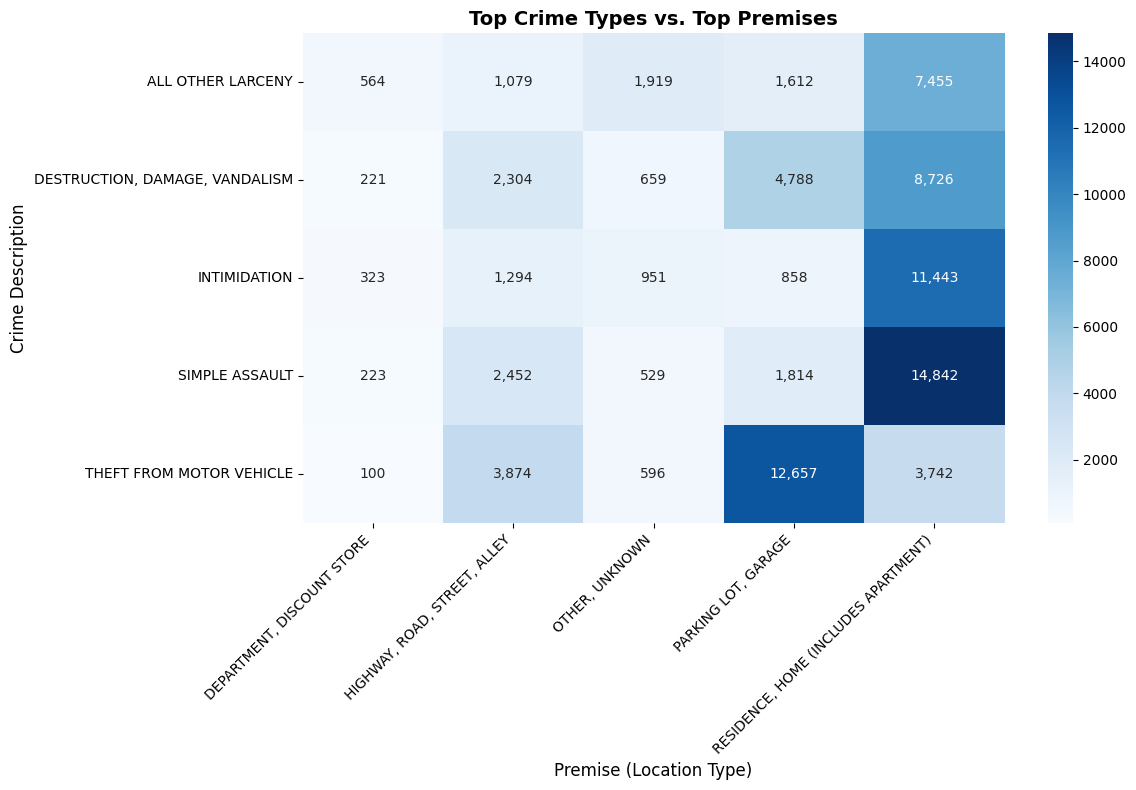

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the figure and explicit axis object (modular setup)
fig, ax = plt.subplots(figsize=(12, 8))

# 2. Plot the heatmap explicitly on 'ax'
sns.heatmap(
    crosstab_result, 
    annot=True, 
    fmt=',d', 
    cmap='Blues', 
    cbar=True, 
    ax=ax
)

# 3. Apply labels and formatting using axis methods
ax.set_title('Top Crime Types vs. Top Premises', fontsize=14, fontweight='bold')
ax.set_xlabel('Premise (Location Type)', fontsize=12)
ax.set_ylabel('Crime Description', fontsize=12)

# Rotate tick labels cleanly
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

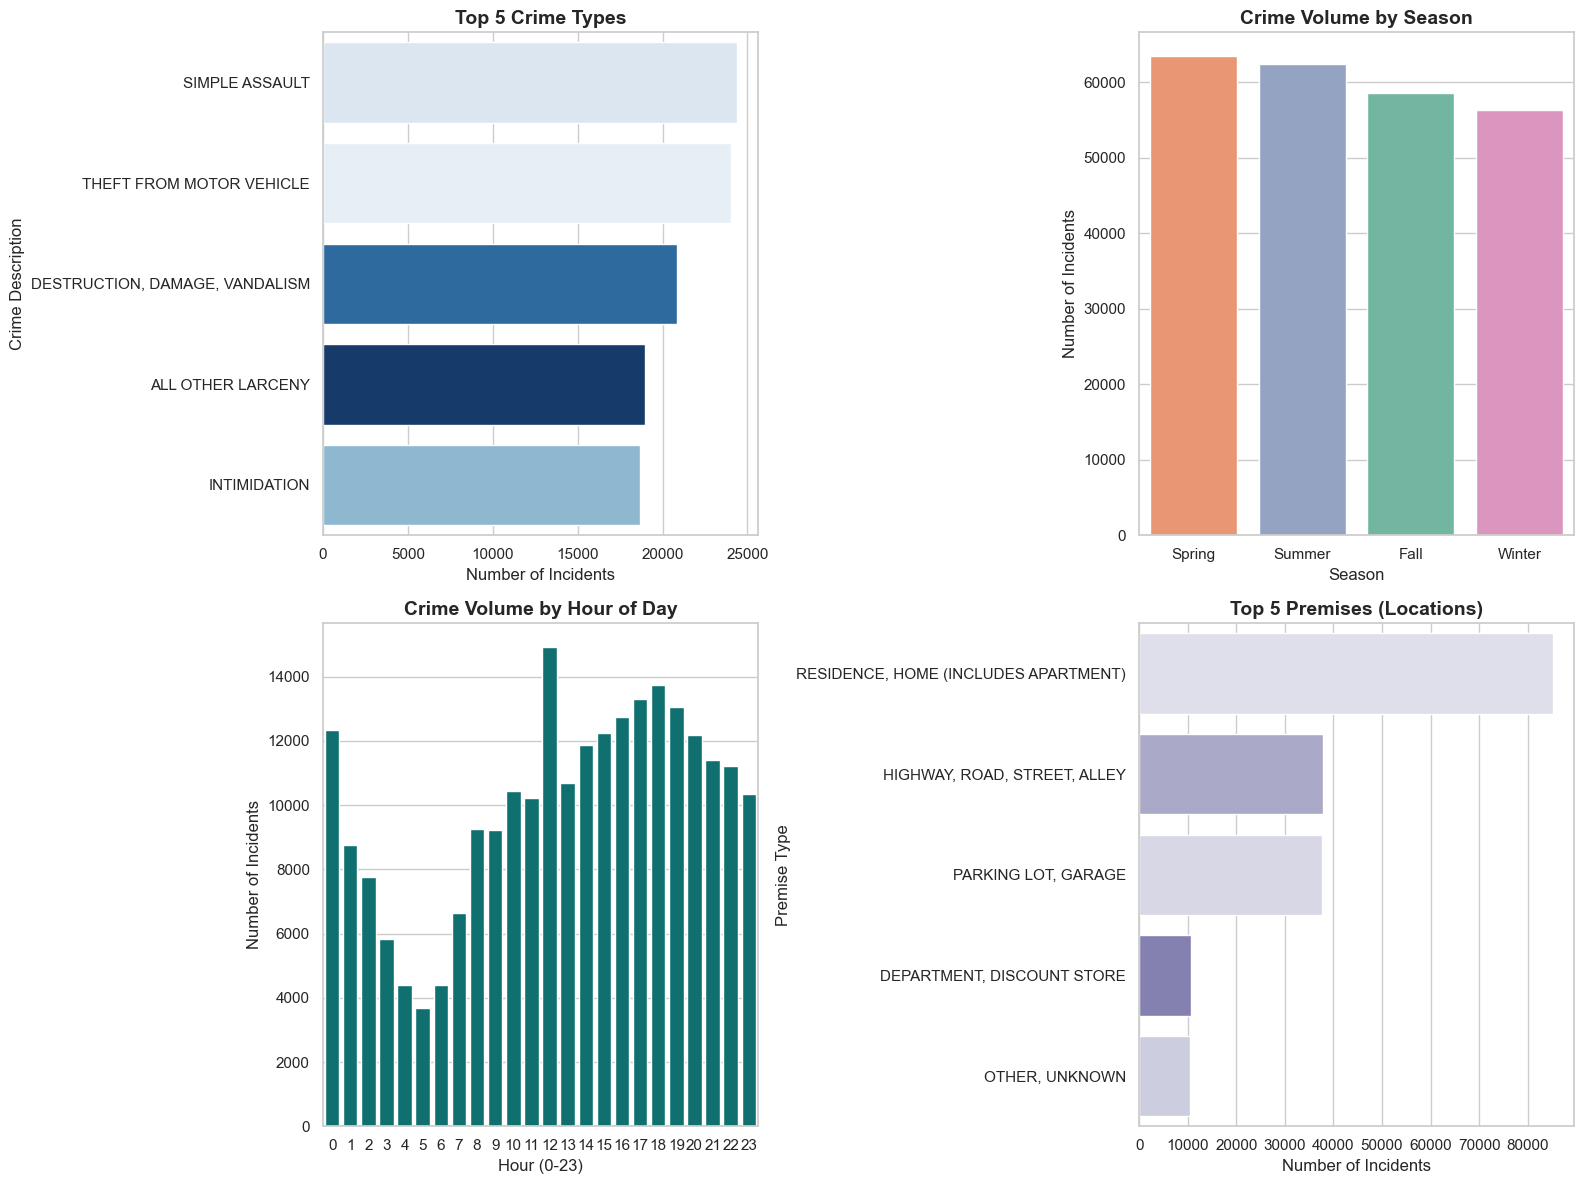

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 5 Crime Descriptions (Top-Left)
top_crimes = df['crime_description'].value_counts().head(5).index
sns.countplot(
    data=df, y='crime_description', order=top_crimes, 
    hue='crime_description', palette='Blues_r', legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Top 5 Crime Types', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Incidents')
axes[0, 0].set_ylabel('Crime Description')

# 2. Crimes by Season (Top-Right)
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.countplot(
    data=df, x='season', order=season_order, 
    hue='season', palette='Set2', legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Crime Volume by Season', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Number of Incidents')

# 3. Crimes by Hour of Day (Bottom-Left)
sns.countplot(
    data=df, x='hour', 
    color='teal',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Crime Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour (0-23)')
axes[1, 0].set_ylabel('Number of Incidents')

# 4. Top 5 Premises (Bottom-Right)
top_premises = df['premise'].value_counts().head(5).index
sns.countplot(
    data=df, y='premise', order=top_premises, 
    hue='premise', palette='Purples_r', legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Top 5 Premises (Locations)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Incidents')
axes[1, 1].set_ylabel('Premise Type')

plt.tight_layout()
plt.show()

## Normalized Categorical Cross-Tabulation

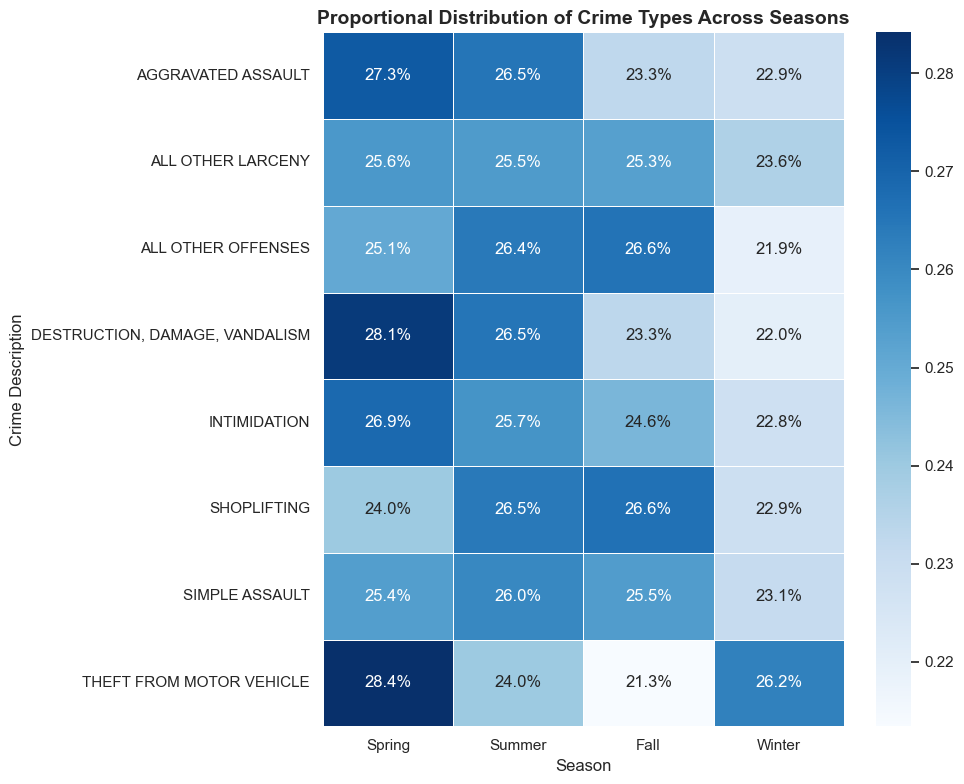

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate top crimes and valid seasons
top_crimes = df['crime_description'].value_counts().head(8).index
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

# 2. Filter dataset
filtered_df = df[df['crime_description'].isin(top_crimes)]

# 3. Create normalized cross-tabulation (row percentages)
norm_ct = pd.crosstab(
    filtered_df['crime_description'], 
    filtered_df['season'], 
    normalize='index'
)[season_order]  # Reorder columns chronologically

# 4. Initialize modular figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 5. Plot heatmap with annotations formatted as percentages
sns.heatmap(
    norm_ct, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    cbar=True, 
    ax=ax,
    linewidths=0.5
)

# 6. Clean labeling
ax.set_title('Proportional Distribution of Crime Types Across Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Crime Description', fontsize=12)

plt.tight_layout()
plt.show()

## Normalized Cross-Tabulation: Crime Types vs. Police Divisions

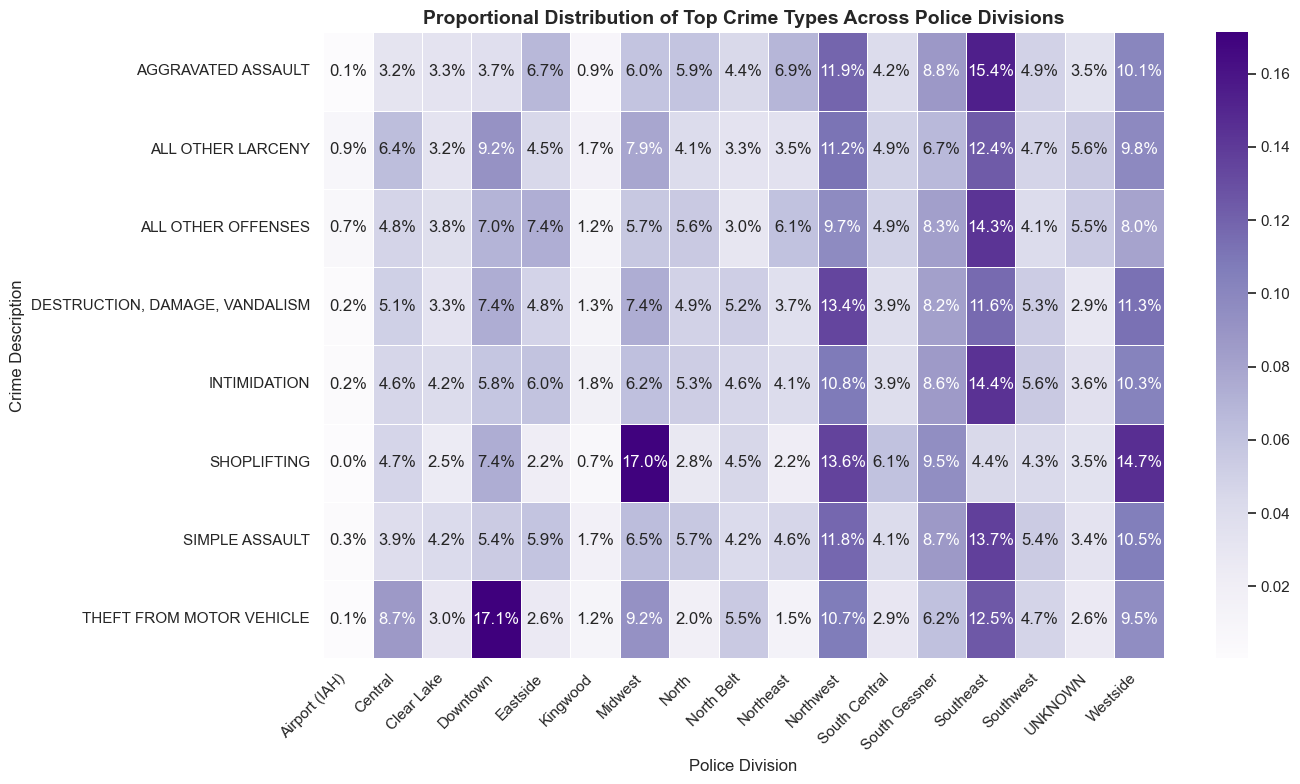

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the top crimes to keep the matrix clean and readable
top_crimes = df['crime_description'].value_counts().head(8).index

# 2. Filter dataset for top crimes
filtered_div_df = df[df['crime_description'].isin(top_crimes)]

# 3. Create normalized cross-tabulation (row percentages: rows sum to 100%)
div_norm_ct = pd.crosstab(
    filtered_div_df['crime_description'], 
    filtered_div_df['police_division'], 
    normalize='index'
)

# 4. Initialize the modular figure and explicit axis object
fig, ax = plt.subplots(figsize=(14, 8))

# 5. Plot the heatmap with percentage formatting
sns.heatmap(
    div_norm_ct, 
    annot=True, 
    fmt='.1%', 
    cmap='Purples', 
    cbar=True, 
    ax=ax,
    linewidths=0.5
)

# 6. Apply clean labeling and formatting
ax.set_title('Proportional Distribution of Top Crime Types Across Police Divisions', fontsize=14, fontweight='bold')
ax.set_xlabel('Police Division', fontsize=12)
ax.set_ylabel('Crime Description', fontsize=12)

# Rotate x-axis division names so they don't overlap
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Normalized Cross-Tabulation: Crime Types vs. Holidays

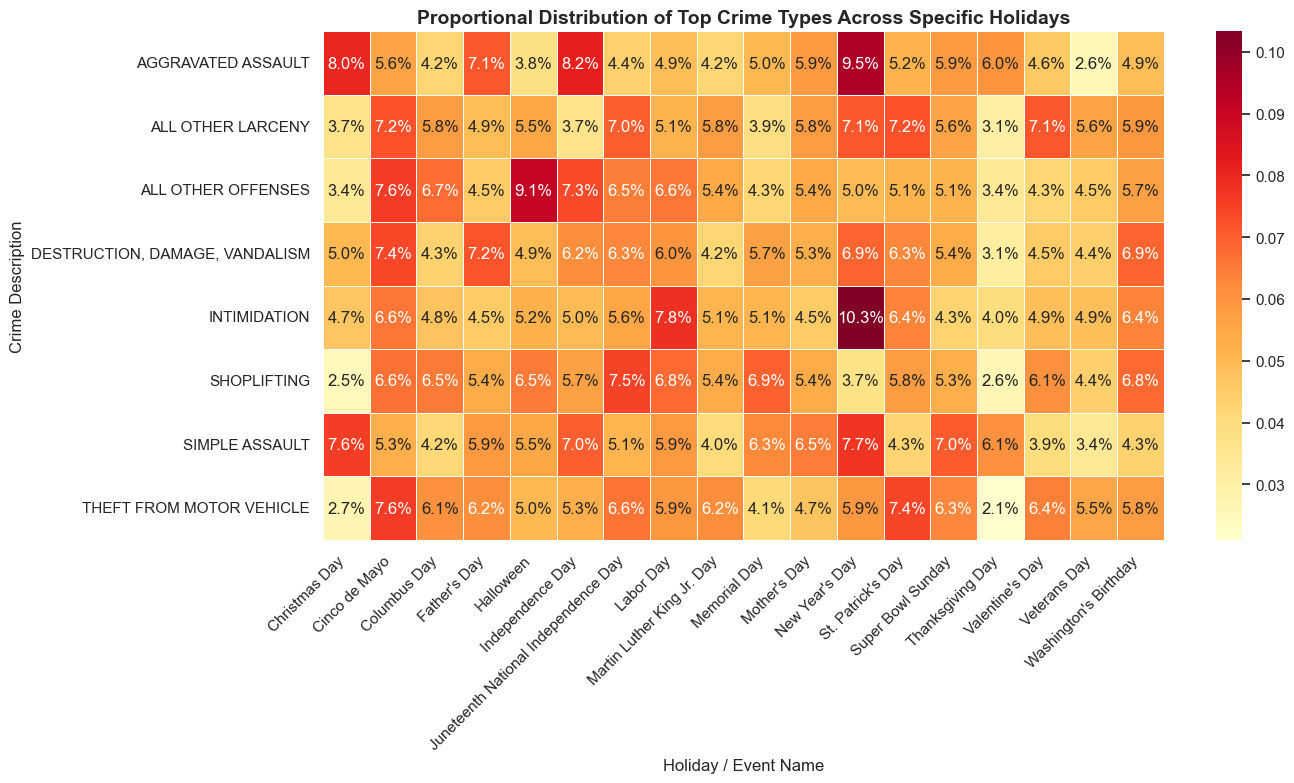

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate top crimes
top_crimes = df['crime_description'].value_counts().head(8).index
filtered_holiday_df = df[df['crime_description'].isin(top_crimes)]

# 2. Drop 'Regular Day' so we focus purely on actual holidays and events
filtered_holiday_df = filtered_holiday_df[filtered_holiday_df['holiday_name'] != 'Regular Day']

# 3. Create normalized cross-tabulation across the remaining holidays
holiday_norm_ct = pd.crosstab(
    filtered_holiday_df['crime_description'], 
    filtered_holiday_df['holiday_name'], 
    normalize='index'
)

# 4. Initialize the modular figure and explicit axis object
fig, ax = plt.subplots(figsize=(14, 8))

# 5. Plot the heatmap with percentage formatting
sns.heatmap(
    holiday_norm_ct, 
    annot=True, 
    fmt='.1%', 
    cmap='YlOrRd', 
    cbar=True, 
    ax=ax,
    linewidths=0.5
)

# 6. Apply clean labeling and formatting
ax.set_title('Proportional Distribution of Top Crime Types Across Specific Holidays', fontsize=14, fontweight='bold')
ax.set_xlabel('Holiday / Event Name', fontsize=12)
ax.set_ylabel('Crime Description', fontsize=12)

# Rotate x-axis holiday names for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 📊 Exploratory Data Analysis & Bivariate Insights
* **Top Offenses & Locations:** Filtered for the top 5 most frequent crime descriptions and premise types to focus on dominant urban patterns[cite: 1].
* **Cross-Tabulation & Heatmap:** Generated a cross-tabulation matrix and visualized the interaction using a Seaborn heatmap (`Top Crime Types vs. Top Premises`) to uncover clustering tendencies between specific offense categories and physical environments[cite: 1].

## Step 5: Temporal Bivariate Analysis (Hour vs. Day of Week)

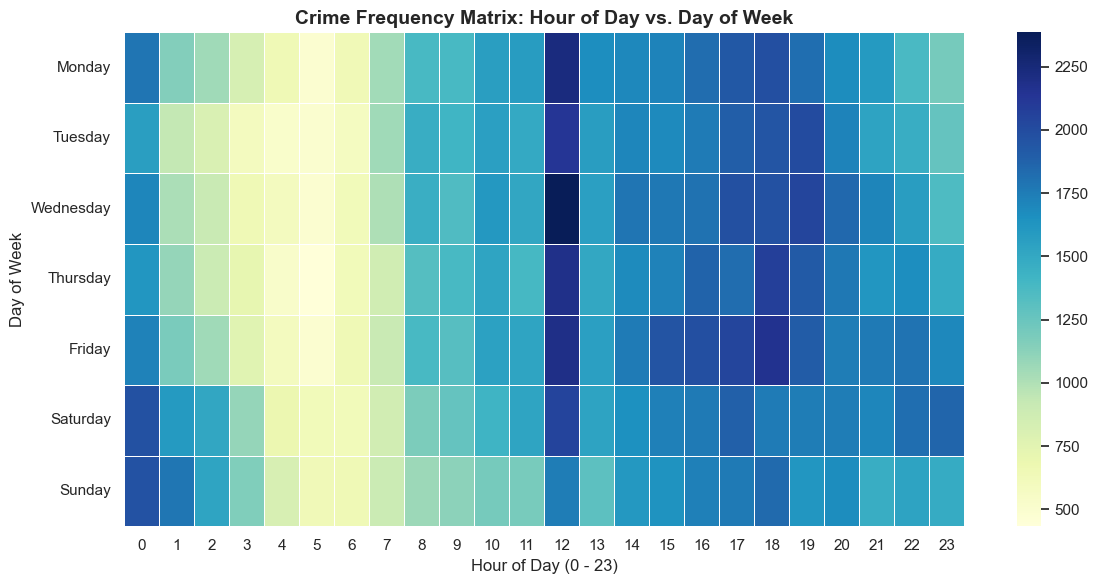

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map numeric days to names if your column is currently integers (0-6 or 1-7)
# Adjust the mapping based on whether your numbers start at 0 (Monday) or 1 (Sunday/Monday)
day_mapping = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

# If your column is numeric, convert it:
if df['day_of_week'].dtype in ['int64', 'int8', 'float64']:
    df['day_name'] = df['day_of_week'].map(day_mapping)
else:
    df['day_name'] = df['day_of_week']

# 2. Build the cross-tabulation using the string day names
temporal_ct = pd.crosstab(df['hour'], df['day_name'])

# 3. Reindex columns to enforce proper chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temporal_ct = temporal_ct.reindex(columns=days_order, fill_value=0)

# 4. Plot the heatmap using your modular fig, ax approach
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    temporal_ct.T, 
    cmap='YlGnBu', 
    fmt='d', 
    cbar=True, 
    ax=ax,
    linewidths=0.5
)

ax.set_title('Crime Frequency Matrix: Hour of Day vs. Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (0 - 23)', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)

plt.tight_layout()
plt.show()

## Step 6: Statistical Inference & Hypothesis Testing

Are specific crime types statistically dependent on the police division where they occur, or is the distribution uniform across the city?

In [24]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create the contingency table (using absolute counts, not normalized)
top_crimes = df['crime_description'].value_counts().head(8).index
subset_df = df[df['crime_description'].isin(top_crimes)]
contingency_table = pd.crosstab(subset_df['crime_description'], subset_df['police_division'])

# 2. Run the Chi-Square test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi2 Statistic: {chi2:.2f}")
print(f"p-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

if p_val < 0.05:
    print("Result: Reject the null hypothesis. Crime types and police divisions are significantly dependent (geographic specialization exists).")
else:
    print("Result: Fail to reject the null hypothesis. No significant association.")

Chi2 Statistic: 12261.38
p-value: 0.0000e+00
Degrees of Freedom: 112
Result: Reject the null hypothesis. Crime types and police divisions are significantly dependent (geographic specialization exists).


Do daily crime volumes in Houston experience a statistically significant shift on holidays and major event days compared to ordinary regular days, or do they follow the baseline standard?

In [25]:
import pandas as pd
from scipy.stats import mannwhitneyu

# 1. Aggregate total crimes per calendar date
daily_crimes = df.groupby(df['date'].dt.date).size().reset_index(name='daily_count')
daily_crimes.rename(columns={'date': 'date_only'}, inplace=True)

# 2. Extract unique date-to-holiday mappings safely
date_holiday_map = df[['date', 'holiday_name']].copy()
date_holiday_map['date_only'] = date_holiday_map['date'].dt.date
daily_holiday_status = date_holiday_map.drop_duplicates(subset=['date_only'])

# 3. Merge the daily counts back with the holiday status
daily_merged = pd.merge(
    daily_crimes, 
    daily_holiday_status[['date_only', 'holiday_name']], 
    on='date_only', 
    how='left'
)

# 4. Create a clean binary classification group
daily_merged['group'] = daily_merged['holiday_name'].apply(
    lambda x: 'Regular Day' if x == 'Regular Day' else 'Holiday/Event'
)

# 5. Separate the two distributions
holiday_counts = daily_merged[daily_merged['group'] == 'Holiday/Event']['daily_count']
regular_counts = daily_merged[daily_merged['group'] == 'Regular Day']['daily_count']

print(f"Mean daily crimes on Holidays/Events: {holiday_counts.mean():.2f}")
print(f"Mean daily crimes on Regular Days: {regular_counts.mean():.2f}\n")

# 6. Run the Mann-Whitney U test
stat, p_val = mannwhitneyu(holiday_counts, regular_counts, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: Reject the null hypothesis. Daily crime volume differs significantly on holidays vs. regular days.")
else:
    print("\nResult: Fail to reject the null hypothesis. No statistically significant difference in daily volume.")

Mean daily crimes on Holidays/Events: 618.22
Mean daily crimes on Regular Days: 661.48

Mann-Whitney U Statistic: 1996.50
p-value: 9.8828e-03

Result: Reject the null hypothesis. Daily crime volume differs significantly on holidays vs. regular days.


Which specific calendar dates or holidays deviate by more than $\pm 2$ standard deviations from Houston's average daily crime volume, signaling abnormal surge (+) or suppression (-)?

In [26]:
import pandas as pd
import numpy as np

# 1. Ensure we are working with the daily aggregated dataset from our previous step
# (daily_merged containing 'date_only', 'daily_count', and 'holiday_name')

# 2. Calculate Mean and Standard Deviation of daily crime counts
mean_crime = daily_merged['daily_count'].mean()
std_crime = daily_merged['daily_count'].std()

# 3. Compute the Z-Score for every day
daily_merged['z_score'] = (daily_merged['daily_count'] - mean_crime) / std_crime

# 4. Filter for extreme statistical outliers (beyond +/- 2 standard deviations)
extreme_days = daily_merged[abs(daily_merged['z_score']) > 2].sort_values(by='z_score', ascending=False)

print(f"Baseline Mean Daily Crimes: {mean_crime:.2f}")
print(f"Standard Deviation: {std_crime:.2f}\n")
print(f"Extreme Days Found (> 2 std deviations): {len(extreme_days)}\n")
print(extreme_days[['date_only', 'holiday_name', 'daily_count', 'z_score']].head(10))

Baseline Mean Daily Crimes: 659.35
Standard Deviation: 56.40

Extreme Days Found (> 2 std deviations): 15

      date_only    holiday_name  daily_count   z_score
120  2025-05-01     Regular Day          888  4.054011
151  2025-06-01     Regular Day          805  2.582435
90   2025-04-01     Regular Day          793  2.369677
181  2025-07-01     Regular Day          791  2.334217
0    2025-01-01  New Year's Day          789  2.298757
31   2025-02-01     Regular Day          785  2.227838
114  2025-04-25     Regular Day          782  2.174649
117  2025-04-28     Regular Day          773  2.015080
337  2025-12-04     Regular Day          543 -2.062781
333  2025-11-30     Regular Day          524 -2.399647


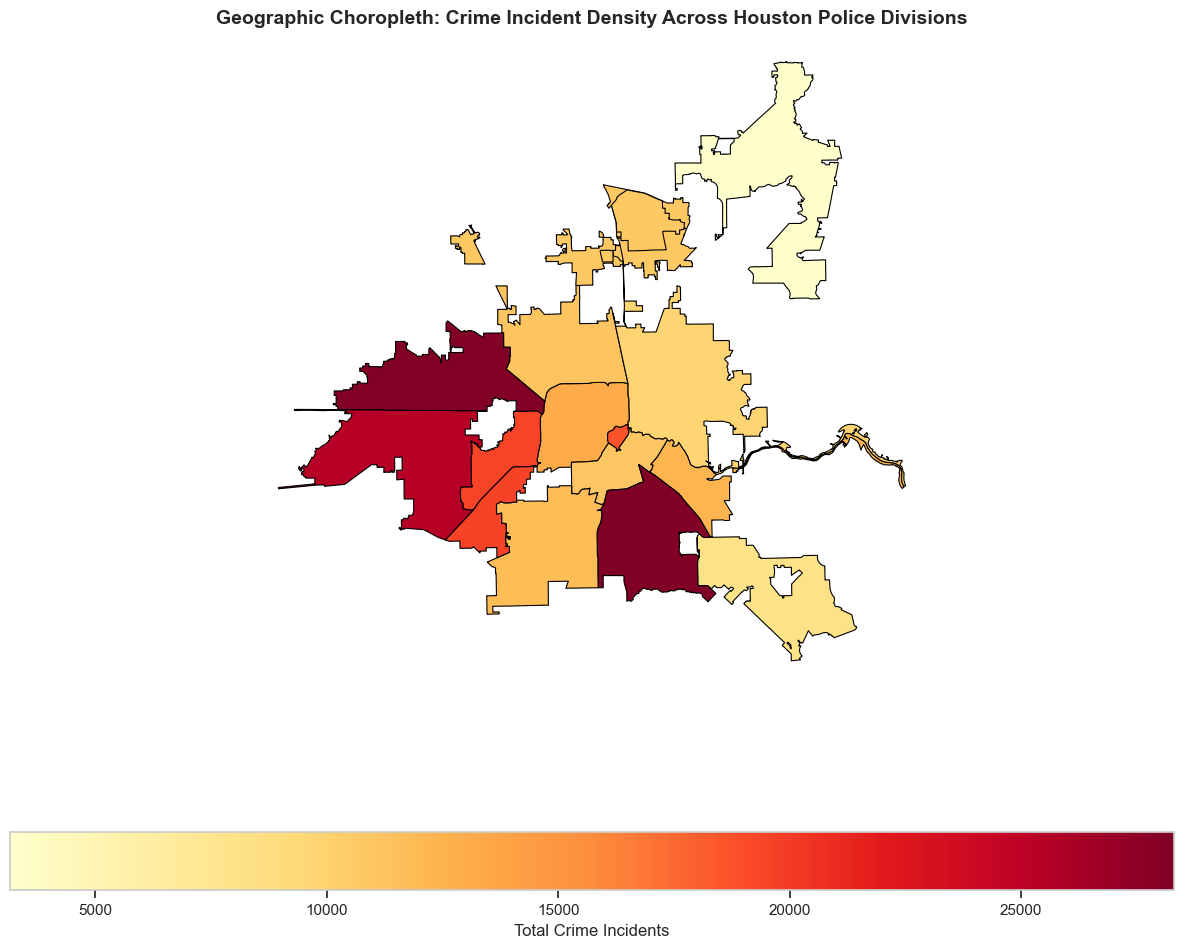

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the Houston police division boundary GeoJSON from your local data folder
divisions_gdf = gpd.read_file("data/COH_Houston_Police_Divisions_view_1596978729761918444.geojson")

# 2. Aggregate your crime counts by division from your main dataframe
division_counts = df['police_division'].value_counts().reset_index()
division_counts.columns = ['police_division', 'incident_count']

# 3. Merge spatial geometries using the correct shapefile column ('Division')
map_gdf = divisions_gdf.merge(
    division_counts, 
    left_on='Division',         # Shapefile column name from your printout
    right_on='police_division', # Crime dataframe column name
    how='left'
)

# 4. Initialize the modular figure and explicit axis object
fig, ax = plt.subplots(figsize=(12, 10))

# 5. Plot the choropleth map
map_gdf.plot(
    column='incident_count',
    cmap='YlOrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Total Crime Incidents', 'orientation': 'horizontal'}
)

# 6. Formatting and layout
ax.set_title('Geographic Choropleth: Crime Incident Density Across Houston Police Divisions', fontsize=14, fontweight='bold')
ax.axis('off')  # Hide lat/long axes for clean cartographic display

plt.tight_layout()
plt.show()

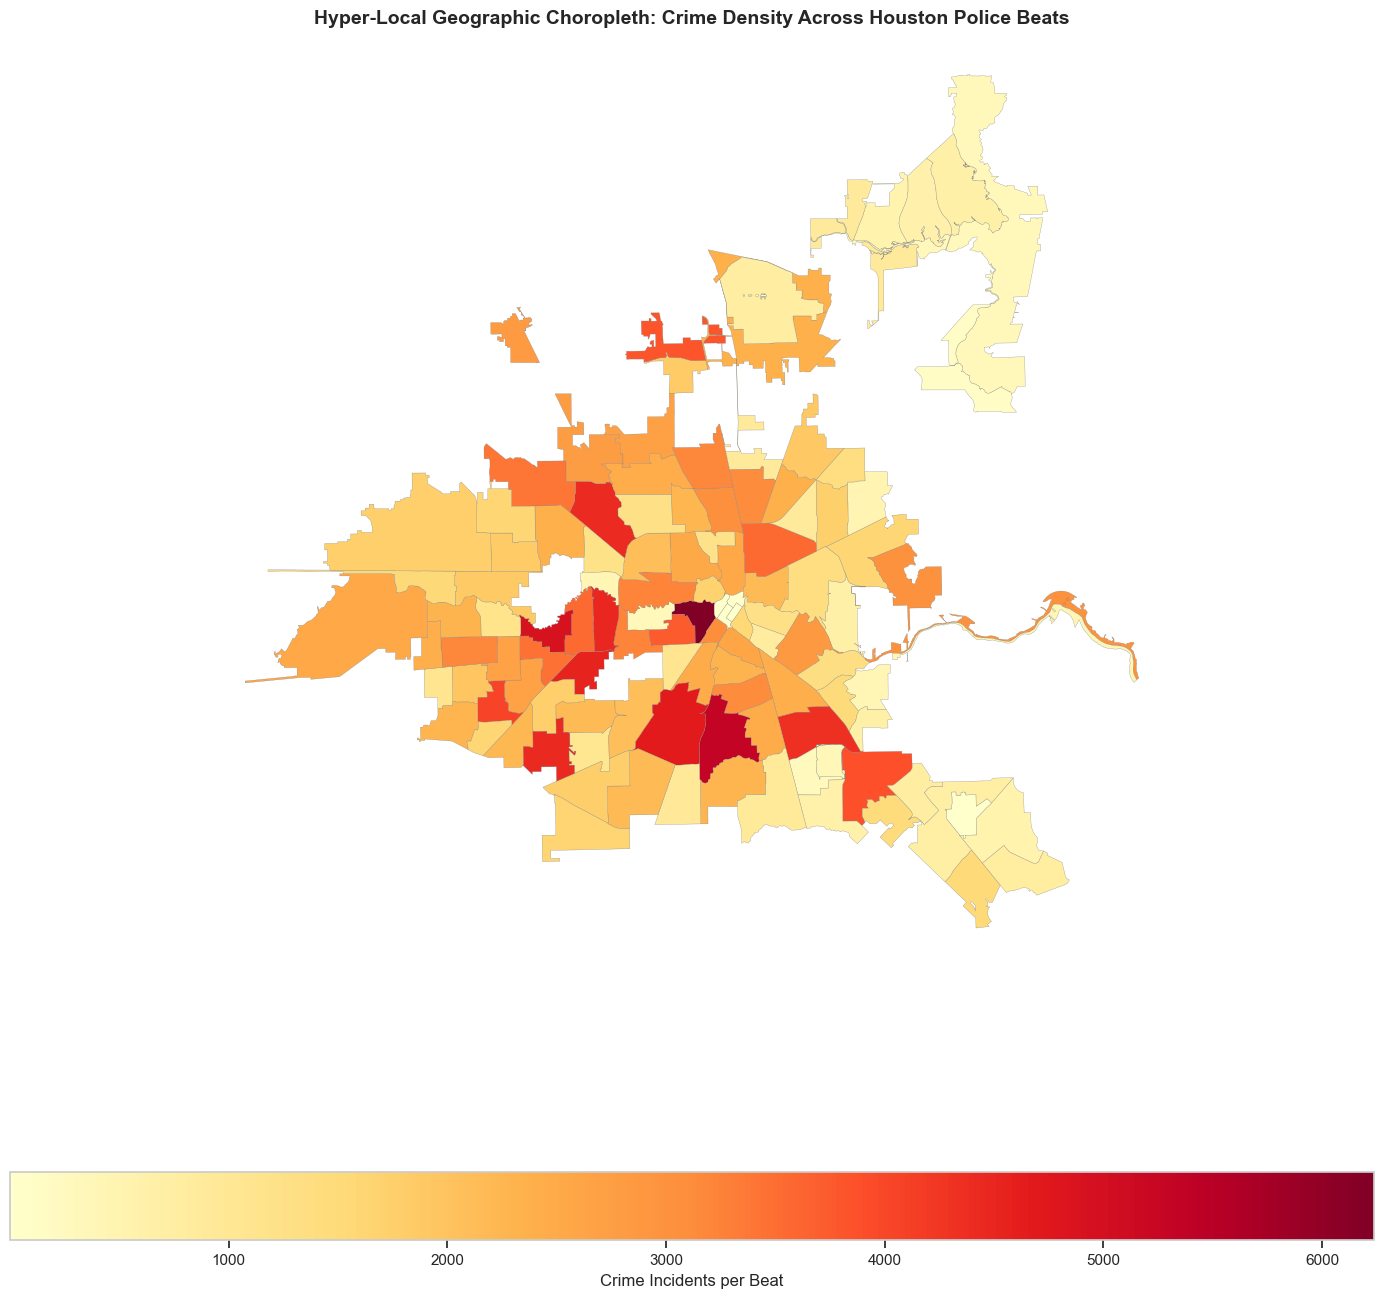

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the Houston police beats boundary GeoJSON
beats_gdf = gpd.read_file("data/COH_Houston_Police_Beats_view_-2568300725230372104.geojson")

# 2. Aggregate your crime counts by beat from your main dataframe
beat_counts = df['beat'].value_counts().reset_index()
beat_counts.columns = ['beat', 'incident_count']

# 3. Merge spatial geometries using 'Beats' from the GeoJSON and 'beat' from your crime data
map_beats_gdf = beats_gdf.merge(
    beat_counts, 
    left_on='Beats',      # Shapefile beat column name
    right_on='beat',      # Crime dataframe beat column name
    how='left'
)

# 4. Initialize the modular figure and explicit axis object
fig, ax = plt.subplots(figsize=(14, 14))

# 5. Plot the hyper-local beat choropleth map
map_beats_gdf.plot(
    column='incident_count',
    cmap='YlOrRd',
    linewidth=0.2,        # Thinner border lines for high-density beat polygons
    ax=ax,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': 'Crime Incidents per Beat', 'orientation': 'horizontal'}
)

# 6. Formatting and layout
ax.set_title('Hyper-Local Geographic Choropleth: Crime Density Across Houston Police Beats', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

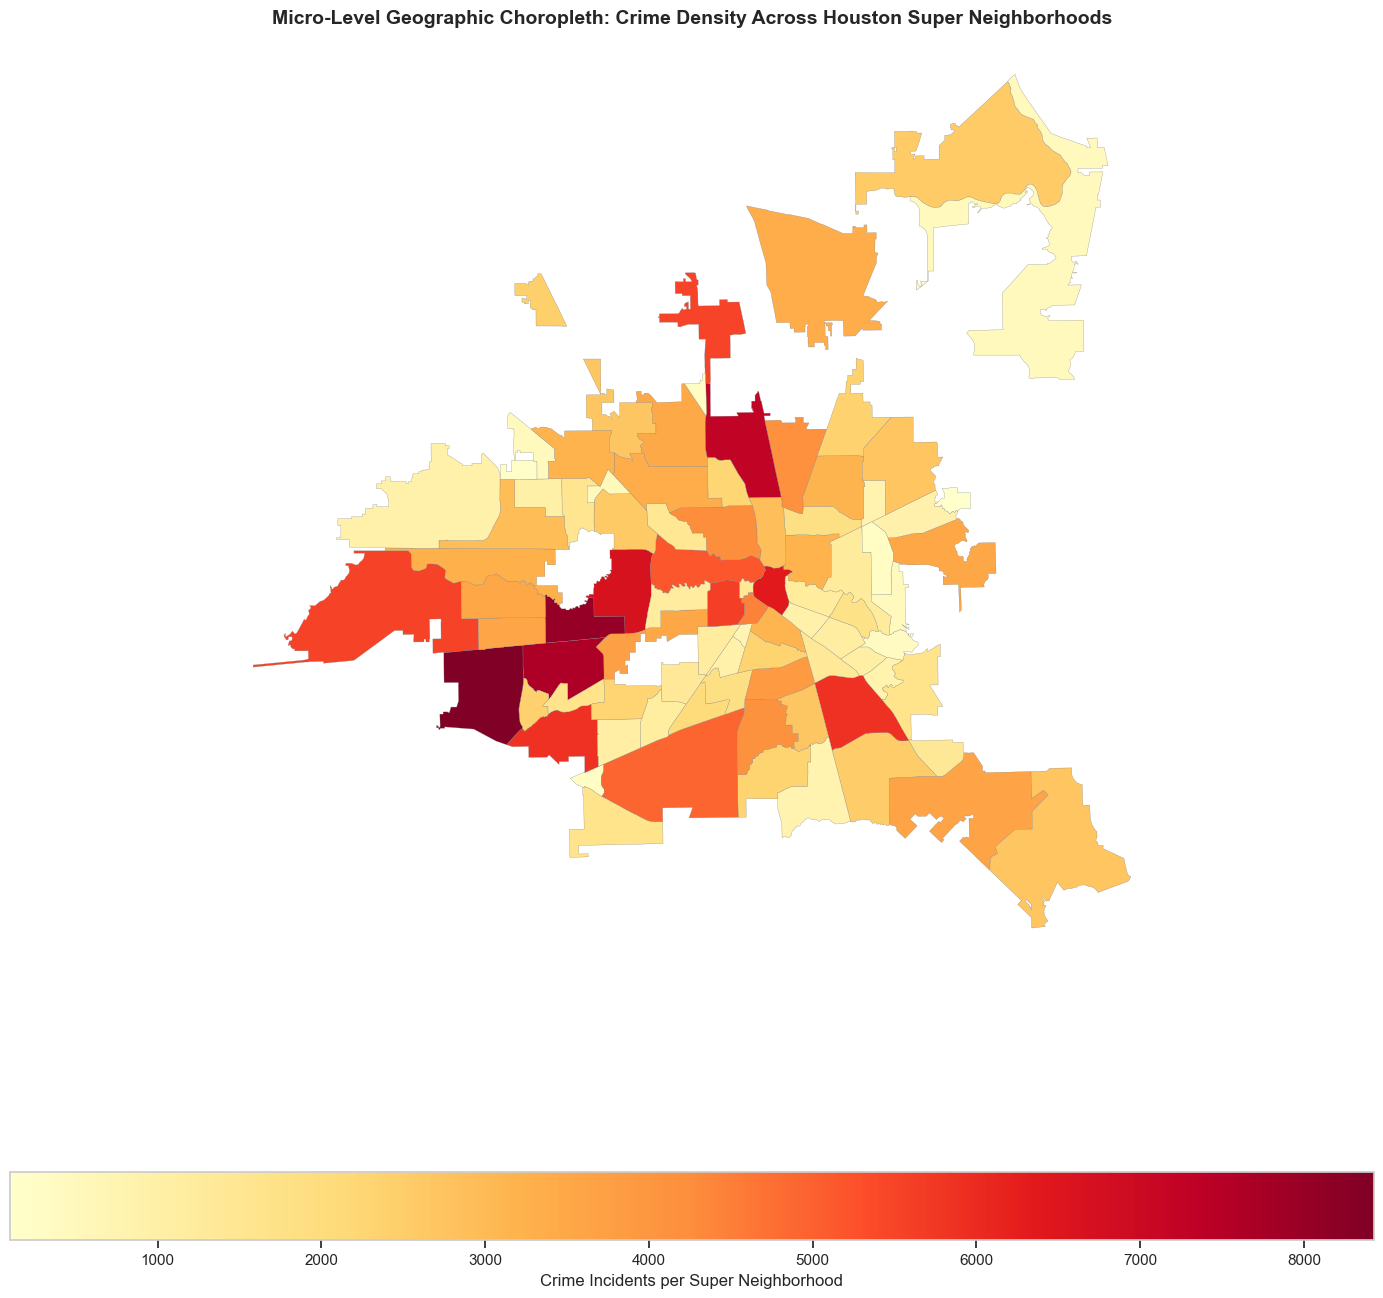

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 1. Load your Houston Super Neighborhoods boundary GeoJSON
neighborhoods_gdf = gpd.read_file("data/COH_Super_Neighborhoods_view_-5705252749292437084.geojson")

# 2. Convert your pandas DataFrame into a GeoDataFrame using your exact coordinate column names
geometry = [Point(xy) for xy in zip(df['map_longitude'], df['map_latitude'])]
crime_points_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# 3. Ensure both datasets share the exact same CRS projection
neighborhoods_gdf = neighborhoods_gdf.to_crs(crime_points_gdf.crs)

# 4. Perform a spatial join (point-in-polygon) to map every crime to a Super Neighborhood
joined_gdf = gpd.sjoin(crime_points_gdf, neighborhoods_gdf, how="inner", predicate="within")

# 5. Aggregate crime counts by the Super Neighborhood identifier ('SNBNAME')
neigh_counts = joined_gdf['SNBNAME'].value_counts().reset_index()
neigh_counts.columns = ['SNBNAME', 'incident_count']

# 6. Merge the aggregated counts back into the neighborhood polygon geometries
map_neigh_gdf = neighborhoods_gdf.merge(neigh_counts, on='SNBNAME', how='left')

# 7. Initialize the modular figure and plot the choropleth map
fig, ax = plt.subplots(figsize=(14, 14))

map_neigh_gdf.plot(
    column='incident_count',
    cmap='YlOrRd',
    linewidth=0.2,
    ax=ax,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': 'Crime Incidents per Super Neighborhood', 'orientation': 'horizontal'}
)

# 8. Formatting and display
ax.set_title('Micro-Level Geographic Choropleth: Crime Density Across Houston Super Neighborhoods', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()